# 5절 토이 실험의 데이터는 어떻게 구성되는가

노트북 `dino_collapse_cross_entropy.py`의 5절은 2D 평면 위 점 몇 개로 DINO의 붕괴를 재현한다.
데이터 생성기는 딱 이것뿐이다.

```python
def make_data(n_per_cluster=128, n_clusters=6, radius=3.0, spread=0.3, seed=0):
    angles  = torch.arange(n_clusters) * (2 * math.pi / n_clusters)
    centers = torch.stack([radius * angles.cos(), radius * angles.sin()], -1)
    X = (centers[:, None, :] + spread * torch.randn(n_clusters, n_per_cluster, 2)).reshape(-1, 2)
    y = torch.arange(n_clusters).repeat_interleave(n_per_cluster)
    return X, y

def augment(x, sigma=0.7):
    return x + sigma * torch.randn_like(x)
```

**"이미지" 하나 = 점 하나.** 그 점에 가우시안 노이즈를 더한 것이 "crop"이다.
이 노트북에서 데이터는 장식이 아니라 **실험의 난이도를 직접 정하는 손잡이**다.
아래에서 네 숫자(`n_clusters=6`, `radius=3.0`, `spread=0.3`, `n_per_cluster=128`)와
증강 노이즈 $\sigma=0.7$이 각각 무엇을 결정하는지 계산으로 확인한다.

In [1]:
import math

import numpy as np
import plotly.graph_objects as go
import torch
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython

        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. `make_data` 재현 — 극좌표로 원 위에 균등 배치

클러스터 중심은 반지름 $r$의 원 위에 **각도만 균등하게** 놓인다.

$$\theta_k = k \cdot \frac{2\pi}{n}, \qquad c_k = \bigl(r\cos\theta_k,\; r\sin\theta_k\bigr),
\qquad k = 0,\dots,n-1$$

코드의 `angles = torch.arange(n) * (2*math.pi/n)`이 $\theta_k$,
`centers = stack([r*cos, r*sin], -1)`이 $c_k$에 그대로 대응한다.

각 클러스터의 점은 중심 주변 등방(isotropic) 가우시안이다.

$$x_{k,i} = c_k + \sigma_{\text{spread}}\,\varepsilon_{k,i}, \qquad \varepsilon_{k,i}\sim\mathcal N(0, I_2)$$

인자 4개의 역할을 나누면:

| 인자 | 값 | 무엇을 정하는가 |
|---|---|---|
| `n_clusters` | 6 | **발견해야 할 잠재 구조의 개수** (정답 코드 수) |
| `radius` | 3.0 | 클러스터 중심들이 놓인 원의 크기 → 클러스터 **간격**의 스케일 |
| `spread` | 0.3 | 클러스터 **내부** 퍼짐 = "같은 클래스 안의 다양성" |
| `n_per_cluster` | 128 | 클러스터당 샘플 수 → 전체 $6\times128=768$ "이미지" |

In [2]:
def make_data(n_per_cluster=128, n_clusters=6, radius=3.0, spread=0.3, seed=0):
    """노트북 원본과 동일 (torch.Generator 시드까지 동일)."""
    g = torch.Generator().manual_seed(seed)
    angles = torch.arange(n_clusters) * (2 * math.pi / n_clusters)
    centers = torch.stack([radius * angles.cos(), radius * angles.sin()], -1)
    X = (centers[:, None, :] + spread * torch.randn(n_clusters, n_per_cluster, 2, generator=g)).reshape(-1, 2)
    y = torch.arange(n_clusters).repeat_interleave(n_per_cluster)
    return X, y


def centers_of(n_clusters=6, radius=3.0):
    angles = torch.arange(n_clusters) * (2 * math.pi / n_clusters)
    return torch.stack([radius * angles.cos(), radius * angles.sin()], -1)


def augment(x, sigma=0.7, generator=None):
    if generator is None:
        return x + sigma * torch.randn_like(x)
    return x + sigma * torch.randn(x.shape, generator=generator)


X, y = make_data()
C = centers_of()

print("X.shape =", tuple(X.shape), " y.shape =", tuple(y.shape))
print("클러스터별 개수 =", y.bincount().tolist())
print("중심 좌표 (r=3.0, n=6):")
for k, c in enumerate(C):
    print(f"  k={k}  theta={math.degrees(k * 2 * math.pi / 6):5.1f}deg  c=({c[0]:+.3f}, {c[1]:+.3f})  |c|={c.norm():.3f}")

X.shape = (768, 2)  y.shape = (768,)
클러스터별 개수 = [128, 128, 128, 128, 128, 128]
중심 좌표 (r=3.0, n=6):
  k=0  theta=  0.0deg  c=(+3.000, +0.000)  |c|=3.000
  k=1  theta= 60.0deg  c=(+1.500, +2.598)  |c|=3.000
  k=2  theta=120.0deg  c=(-1.500, +2.598)  |c|=3.000
  k=3  theta=180.0deg  c=(-3.000, -0.000)  |c|=3.000
  k=4  theta=240.0deg  c=(-1.500, -2.598)  |c|=3.000
  k=5  theta=300.0deg  c=(+1.500, -2.598)  |c|=3.000


## 2. 기하학적 수치 — 왜 하필 "간격 3.0"인가

원 위에 균등 배치된 두 **인접** 중심 사이의 거리는 정다각형의 변의 길이다.

$$d_{\text{gap}} = \lVert c_{k+1} - c_k \rVert = 2r\sin\!\left(\frac{\pi}{n}\right)$$

$n=6$이면 $\sin(\pi/6) = 1/2$이므로

$$d_{\text{gap}} = 2r \cdot \tfrac12 = r = 3.0$$

**정육각형은 변의 길이가 반지름과 같다.** 그래서 `radius=3.0`을 고른 순간
클러스터 간격도 정확히 3.0으로 정해진 것이고, 노트북의 "클러스터 간격"이라는 말은 이 3.0을 가리킨다.

이제 세 스케일의 비율:

| 스케일 | 값 | 간격 대비 |
|---|---|---|
| 클러스터 간격 $d_{\text{gap}}$ | 3.0 | 1 |
| 클러스터 내부 퍼짐 $\sigma_{\text{spread}}$ | 0.3 | 1/10 |
| 증강 노이즈 $\sigma_{\text{aug}}$ | 0.7 | **0.233 ≈ 1/4** |

노트북이 "노이즈가 클러스터 간격의 1/4쯤"이라 한 근거가 이것이다: $0.7/3.0 = 0.2\overline{3}$.

결정 경계까지의 거리로 바꿔 읽으면 더 직관적이다. 이웃 중심으로 넘어가려면 절반인 $1.5$를 이동해야 하고,
그것은 $1.5/0.7 \approx 2.14\,\sigma_{\text{aug}}$다 — **2σ가 조금 넘는 사건**, 즉 드물지만 확실히 일어난다.

In [3]:
n, r = 6, 3.0
d_gap = 2 * r * math.sin(math.pi / n)
d_neighbor_actual = (C[1] - C[0]).norm().item()
spread, sigma_aug = 0.3, 0.7

print(f"2 r sin(pi/n) = 2*{r}*sin(pi/{n}) = {d_gap:.6f}")
print(f"실제 |c1 - c0|  = {d_neighbor_actual:.6f}   (일치: {math.isclose(d_gap, d_neighbor_actual, abs_tol=1e-5)})")
print(f"반지름과 같은가? r={r} -> 정육각형이므로 변=반지름: {math.isclose(d_gap, r, abs_tol=1e-9)}")
print()
print(f"spread/gap     = {spread/d_gap:.4f}  (~1/{d_gap/spread:.0f})")
print(f"sigma_aug/gap  = {sigma_aug/d_gap:.4f}  (~1/{d_gap/sigma_aug:.1f})   <- 노트북의 '간격의 1/4쯤'")
print(f"sigma_aug/spread = {sigma_aug/spread:.4f}  (증강이 내부 퍼짐보다 {sigma_aug/spread:.1f}배 크다)")
print()
half = d_gap / 2
print(f"결정 경계까지 거리 = gap/2 = {half:.2f} = {half/sigma_aug:.2f} sigma_aug")
# 1차원 성분만 봐도: 이웃 방향 좌표가 +1.5 이상 튈 확률
p_1d = 0.5 * math.erfc(half / (math.sqrt(2) * math.hypot(spread, sigma_aug)))
print(f"참고: 1D 근사 P(이웃 방향으로 {half:.2f} 이상 이동) = {p_1d:.4f}  (총 std={math.hypot(spread, sigma_aug):.4f})")

2 r sin(pi/n) = 2*3.0*sin(pi/6) = 3.000000
실제 |c1 - c0|  = 3.000000   (일치: True)
반지름과 같은가? r=3.0 -> 정육각형이므로 변=반지름: True

spread/gap     = 0.1000  (~1/10)
sigma_aug/gap  = 0.2333  (~1/4.3)   <- 노트북의 '간격의 1/4쯤'
sigma_aug/spread = 2.3333  (증강이 내부 퍼짐보다 2.3배 크다)

결정 경계까지 거리 = gap/2 = 1.50 = 2.14 sigma_aug
참고: 1D 근사 P(이웃 방향으로 1.50 이상 이동) = 0.0244  (총 std=0.7616)


## 3. 증강 난이도의 정량화 — "혼동률"

자기지도 과제의 난이도는 한 숫자로 요약할 수 있다:

$$\text{confusion}(\sigma) \;=\; \Pr\Bigl[\arg\min_j \lVert v - c_j\rVert \neq k \;\Big|\; v = c_k + \sigma_{\text{spread}}\varepsilon_1 + \sigma\varepsilon_2\Bigr]$$

즉 **증강된 crop이 원래 클러스터가 아닌 다른 클러스터 중심에 더 가까워질 확률**이다.
이 값이 0에 가까우면 과제가 너무 쉽고(증강이 사실상 아무것도 안 함), 5/6에 가까우면 라벨 정보가 사라진다.
몬테카를로로 $\sigma$를 0.1~1.5까지 스윕한다.

In [4]:
def confusion_rate(sigma, n_clusters=6, radius=3.0, spread=0.3, n=200_000, seed=1):
    """증강된 점이 '가장 가까운 중심' 기준으로 다른 클러스터로 넘어갈 확률."""
    g = torch.Generator().manual_seed(seed)
    cs = centers_of(n_clusters, radius)
    lbl = torch.randint(0, n_clusters, (n,), generator=g)
    x = cs[lbl] + spread * torch.randn(n, 2, generator=g)           # 원본 "이미지"
    v = x + sigma * torch.randn(n, 2, generator=g)                  # crop
    pred = torch.cdist(v, cs).argmin(-1)
    return (pred != lbl).float().mean().item()


base_conf_clean = confusion_rate(0.0)
base_conf_07 = confusion_rate(0.7)
print(f"증강 없음 (spread=0.3만)  혼동률 = {base_conf_clean:.5f}")
print(f"sigma=0.7 (노트북 설정)   혼동률 = {base_conf_07:.5f}   -> 약 {base_conf_07*100:.1f}%의 crop이 이웃 쪽으로 넘어간다")
print()

sigmas = np.round(np.arange(0.1, 1.51, 0.1), 2)
conf = np.array([confusion_rate(float(s)) for s in sigmas])
for s, c in zip(sigmas, conf):
    mark = "  <-- 노트북" if abs(s - 0.7) < 1e-9 else ""
    print(f"  sigma={s:.1f}  (gap의 {s/3.0:.2f}배)  혼동률={c:.4f}{mark}")
print(f"\n완전 무작위 상한 = (n-1)/n = {5/6:.4f}")

증강 없음 (spread=0.3만)  혼동률 = 0.00000
sigma=0.7 (노트북 설정)   혼동률 = 0.04936   -> 약 4.9%의 crop이 이웃 쪽으로 넘어간다

  sigma=0.1  (gap의 0.03배)  혼동률=0.0000
  sigma=0.2  (gap의 0.07배)  혼동률=0.0000
  sigma=0.3  (gap의 0.10배)  혼동률=0.0005
  sigma=0.4  (gap의 0.13배)  혼동률=0.0027
  sigma=0.5  (gap의 0.17배)  혼동률=0.0103
  sigma=0.6  (gap의 0.20배)  혼동률=0.0258
  sigma=0.7  (gap의 0.23배)  혼동률=0.0494  <-- 노트북
  sigma=0.8  (gap의 0.27배)  혼동률=0.0792
  sigma=0.9  (gap의 0.30배)  혼동률=0.1141
  sigma=1.0  (gap의 0.33배)  혼동률=0.1512
  sigma=1.1  (gap의 0.37배)  혼동률=0.1884
  sigma=1.2  (gap의 0.40배)  혼동률=0.2241
  sigma=1.3  (gap의 0.43배)  혼동률=0.2592
  sigma=1.4  (gap의 0.47배)  혼동률=0.2924
  sigma=1.5  (gap의 0.50배)  혼동률=0.3230

완전 무작위 상한 = (n-1)/n = 0.8333


곡선을 읽는 법:

- $\sigma \le 0.3$ (내부 퍼짐과 같거나 작음): 혼동률 사실상 0 — crop 두 개가 항상 같은 클러스터 안에 있다.
  student가 "가까운 점끼리 묶기"만 해도 풀리는 **너무 쉬운 과제**.
- $\sigma = 0.7$: 4.9%. 대부분은 같은 클러스터지만 **20번에 한 번쯤 틀린다**.
  노트북이 "실제 crop이 배경만 잡을 때와 비슷한 난이도"라 한 지점 — 신호는 있지만 잡음이 섞인다.
- $\sigma \ge 1.2$: 22% 이상. 라벨 신호가 급격히 희석되어 `code_acc`가 의미를 잃기 시작한다.

곡선이 0.3~0.7 구간에서 급하게 꺾이는 이유는 앞의 $2.14\sigma$ 계산 그대로다.
경계까지의 거리가 $\sigma$의 몇 배인지가 가우시안 꼬리 확률을 지수적으로 바꾸기 때문이다.

## 4. 왜 이 설계인가 — 6개 클러스터 vs `out_dim=32`

데이터의 클러스터 수(6)와 head의 출력 차원(`out_dim=32`)이 **일부러 다르다**.

- 6 = 모델이 **발견해야 할 잠재 구조**의 개수. 데이터에만 존재하고 모델은 모른다.
- 32 = 모델이 **쓸 수 있는 코드북**의 크기. 6보다 넉넉하게 크다.

만약 `out_dim = 6`이었다면 "6개를 골고루 쓴다"는 것이 거의 강제되어(centering + sharpening이
균등 분포를 밀어붙이므로) 성공 여부를 판별할 수 없다.
32개 중 **정확히 6개만** 쓰이는지를 볼 수 있어야 `top_share`, `h_mean`, `code_acc`가 진단이 된다.

$$H_{\max} = \log 32 = 3.466, \qquad H_{\text{건강}} \approx \log 6 = 1.792, \qquad H_{\text{붕괴}} \to 0$$

즉 건강한 `h_mean`은 최대값의 **절반쯤**에서 멈춘다 — 이 "중간 어딘가"라는 여지가
클러스터 수 < 코드 수일 때만 생긴다.

In [5]:
for K, ncl in [(6, 6), (32, 6), (32, 30)]:
    print(
        f"out_dim={K:2d}, n_clusters={ncl:2d} | log K = {math.log(K):.3f} | "
        f"건강한 h_mean ~ log(n_clusters) = {math.log(ncl):.3f} | "
        f"여유(진단 가능 폭) = {math.log(K)-math.log(ncl):.3f} | "
        f"건강한 top_share = 1/{ncl} = {1/ncl:.3f}"
    )
print()
print(f"노트북 설정: 32개 코드 중 6개만 쓰면 top_share={1/6:.3f}, h_mean={math.log(6):.3f} (최대 {math.log(32):.3f}의 {math.log(6)/math.log(32)*100:.0f}%)")

out_dim= 6, n_clusters= 6 | log K = 1.792 | 건강한 h_mean ~ log(n_clusters) = 1.792 | 여유(진단 가능 폭) = 0.000 | 건강한 top_share = 1/6 = 0.167
out_dim=32, n_clusters= 6 | log K = 3.466 | 건강한 h_mean ~ log(n_clusters) = 1.792 | 여유(진단 가능 폭) = 1.674 | 건강한 top_share = 1/6 = 0.167
out_dim=32, n_clusters=30 | log K = 3.466 | 건강한 h_mean ~ log(n_clusters) = 3.401 | 여유(진단 가능 폭) = 0.065 | 건강한 top_share = 1/30 = 0.033

노트북 설정: 32개 코드 중 6개만 쓰면 top_share=0.167, h_mean=1.792 (최대 3.466의 52%)


## 5. 파라미터를 바꾸면 — 실제 변형 두 가지

**(A) `spread`를 키우면** ($0.3 \to 1.0$): 클러스터가 서로 번져서 증강 없이도 이미 겹친다.
"발견해야 할 6개 구조"라는 전제 자체가 무너지고 `code_acc`의 상한이 1.0보다 훨씬 낮아진다.

**(B) `n_clusters`를 `out_dim`에 가깝게 키우면** ($6 \to 24$, `out_dim=32`): 두 가지가 동시에 일어난다.
간격이 $2r\sin(\pi/24)$로 줄어 과제가 어려워지고, 동시에 $\log 24 \approx 3.18$이 $\log 32 = 3.47$에
바짝 붙어 "균등 붕괴"와 "건강"을 엔트로피로 구분할 수 없게 된다.

In [6]:
print("변형 (A) spread 스윕 — 간격은 3.0 고정")
for sp in [0.3, 0.6, 1.0, 1.5]:
    c0 = confusion_rate(0.0, spread=sp)
    c7 = confusion_rate(0.7, spread=sp)
    print(f"  spread={sp:.1f} (gap의 {sp/3.0:.2f}) | 증강 전 혼동률={c0:.4f} | sigma=0.7 후={c7:.4f}")
print()
print("변형 (B) n_clusters 스윕 — radius=3.0 고정, out_dim=32 가정")
for nc in [6, 12, 24, 32]:
    gap = 2 * 3.0 * math.sin(math.pi / nc)
    c7 = confusion_rate(0.7, n_clusters=nc)
    print(
        f"  n={nc:2d} | gap=2*3*sin(pi/{nc})={gap:.3f} | sigma/gap={0.7/gap:.2f} | "
        f"sigma=0.7 혼동률={c7:.4f} | log n={math.log(nc):.3f} vs log 32={math.log(32):.3f}"
    )

변형 (A) spread 스윕 — 간격은 3.0 고정
  spread=0.3 (gap의 0.10) | 증강 전 혼동률=0.0000 | sigma=0.7 후=0.0494
  spread=0.6 (gap의 0.20) | 증강 전 혼동률=0.0124 | sigma=0.7 후=0.1049
  spread=1.0 (gap의 0.33) | 증강 전 혼동률=0.1331 | sigma=0.7 후=0.2187
  spread=1.5 (gap의 0.50) | 증강 전 혼동률=0.3152 | sigma=0.7 후=0.3608

변형 (B) n_clusters 스윕 — radius=3.0 고정, out_dim=32 가정
  n= 6 | gap=2*3*sin(pi/6)=3.000 | sigma/gap=0.23 | sigma=0.7 혼동률=0.0494 | log n=1.792 vs log 32=3.466
  n=12 | gap=2*3*sin(pi/12)=1.553 | sigma/gap=0.45 | sigma=0.7 혼동률=0.3076 | log n=2.485 vs log 32=3.466
  n=24 | gap=2*3*sin(pi/24)=0.783 | sigma/gap=0.89 | sigma=0.7 혼동률=0.6064 | log n=3.178 vs log 32=3.466
  n=32 | gap=2*3*sin(pi/32)=0.588 | sigma/gap=1.19 | sigma=0.7 혼동률=0.6990 | log n=3.466 vs log 32=3.466


`n=24`에서 혼동률이 61%까지 치솟는다 — 증강된 crop의 다수가 엉뚱한 클러스터에 붙는다.
즉 클러스터 수를 코드 수에 붙이는 것은 "코드북을 다 쓰게 만들자"는 의도였더라도
**과제를 사실상 불가능하게** 만들고, 동시에 진단 지표까지 무력화한다.
`n_clusters=6`, `out_dim=32`, `radius=3.0`, `sigma=0.7`의 조합은 이 세 제약
(풀 수 있을 만큼 쉬움 / 증강이 의미 있을 만큼 어려움 / 코드북 사용량이 진단이 됨)의 교집합이다.

## 6. 시각화 — 2×2

(a) 원본 6클러스터 + 중심/반지름, (b) $\sigma=0.7$ crop, (c) 같은 점의 두 crop을 이은 선,
(d) $\sigma$ vs 혼동률 곡선.

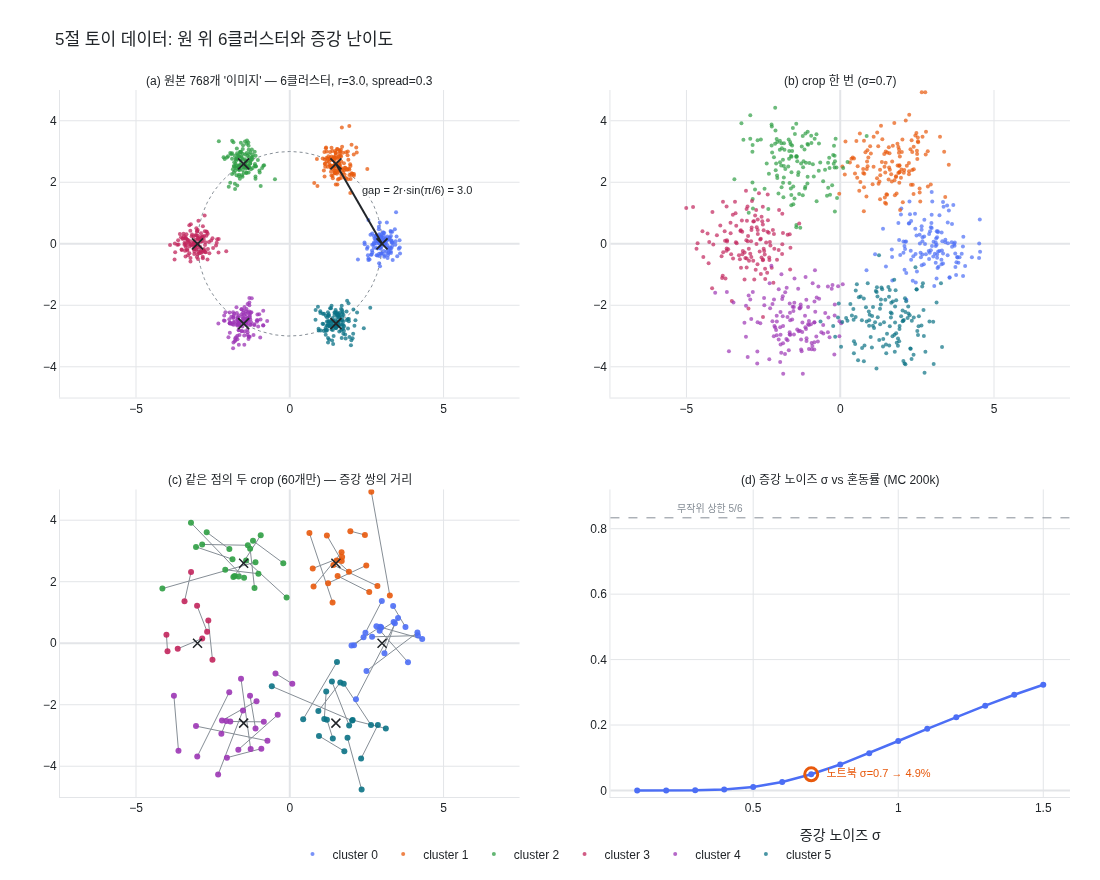

saved expy.png


In [7]:
PALETTE = ["#4C6EF5", "#E8590C", "#2F9E44", "#C2255C", "#9C36B5", "#0B7285"]
GRID, INK, MUTED = "#E3E5E8", "#212529", "#868E96"

g_vis = torch.Generator().manual_seed(7)
V1 = augment(X, 0.7, generator=g_vis)
V2 = augment(X, 0.7, generator=g_vis)

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "(a) 원본 768개 '이미지' — 6클러스터, r=3.0, spread=0.3",
        "(b) crop 한 번 (σ=0.7)",
        "(c) 같은 점의 두 crop (60개만) — 증강 쌍의 거리",
        "(d) 증강 노이즈 σ vs 혼동률 (MC 200k)",
    ),
    horizontal_spacing=0.09,
    vertical_spacing=0.13,
)

# --- (a) 원본 + 중심 + 반지름 원
th = np.linspace(0, 2 * np.pi, 361)
fig.add_trace(
    go.Scatter(
        x=3.0 * np.cos(th), y=3.0 * np.sin(th), mode="lines",
        line=dict(color=MUTED, width=1, dash="dot"), hoverinfo="skip", showlegend=False,
    ),
    row=1, col=1,
)
for k in range(6):
    m = (y == k).numpy()
    fig.add_trace(
        go.Scatter(
            x=X[m, 0].numpy(), y=X[m, 1].numpy(), mode="markers",
            marker=dict(size=4, color=PALETTE[k], opacity=0.75),
            name=f"cluster {k}", legendgroup=f"c{k}", showlegend=True,
            hovertemplate=f"cluster {k}<br>(%{{x:.2f}}, %{{y:.2f}})<extra></extra>",
        ),
        row=1, col=1,
    )
fig.add_trace(
    go.Scatter(
        x=C[:, 0].numpy(), y=C[:, 1].numpy(), mode="markers",
        marker=dict(size=11, color="white", line=dict(color=INK, width=1.8), symbol="x-thin"),
        showlegend=False, hovertemplate="center<br>(%{x:.2f}, %{y:.2f})<extra></extra>",
    ),
    row=1, col=1,
)
# 인접 중심 사이 거리 = 3.0 표시
fig.add_trace(
    go.Scatter(
        x=[C[0, 0].item(), C[1, 0].item()], y=[C[0, 1].item(), C[1, 1].item()],
        mode="lines", line=dict(color=INK, width=2),
        showlegend=False, hoverinfo="skip",
    ),
    row=1, col=1,
)
fig.add_annotation(
    x=(C[0, 0].item() + C[1, 0].item()) / 2, y=(C[0, 1].item() + C[1, 1].item()) / 2,
    text="gap = 2r·sin(π/6) = 3.0", showarrow=False,
    xshift=58, yshift=14, font=dict(size=11, color=INK),
    bgcolor="rgba(255,255,255,0.85)", row=1, col=1,
)

# --- (b) crop 한 번
for k in range(6):
    m = (y == k).numpy()
    fig.add_trace(
        go.Scatter(
            x=V1[m, 0].numpy(), y=V1[m, 1].numpy(), mode="markers",
            marker=dict(size=4, color=PALETTE[k], opacity=0.7),
            legendgroup=f"c{k}", showlegend=False,
            hovertemplate=f"cluster {k} crop<extra></extra>",
        ),
        row=1, col=2,
    )

# --- (c) 두 crop을 선으로 연결
sub = torch.randperm(len(X), generator=torch.Generator().manual_seed(3))[:60]
lx, ly, lc = [], [], []
for i in sub.tolist():
    lx += [V1[i, 0].item(), V2[i, 0].item(), None]
    ly += [V1[i, 1].item(), V2[i, 1].item(), None]
fig.add_trace(
    go.Scatter(x=lx, y=ly, mode="lines", line=dict(color=MUTED, width=1),
               hoverinfo="skip", showlegend=False),
    row=2, col=1,
)
for k in range(6):
    m = np.isin(sub.numpy(), np.where((y == k).numpy())[0])
    idx = sub.numpy()[m]
    if len(idx) == 0:
        continue
    fig.add_trace(
        go.Scatter(
            x=np.concatenate([V1[idx, 0].numpy(), V2[idx, 0].numpy()]),
            y=np.concatenate([V1[idx, 1].numpy(), V2[idx, 1].numpy()]),
            mode="markers", marker=dict(size=6, color=PALETTE[k], opacity=0.9),
            legendgroup=f"c{k}", showlegend=False,
            hovertemplate=f"cluster {k}<extra></extra>",
        ),
        row=2, col=1,
    )
fig.add_trace(
    go.Scatter(
        x=C[:, 0].numpy(), y=C[:, 1].numpy(), mode="markers",
        marker=dict(size=9, color="white", line=dict(color=INK, width=1.5), symbol="x-thin"),
        showlegend=False, hoverinfo="skip",
    ),
    row=2, col=1,
)

# --- (d) σ vs 혼동률
fig.add_trace(
    go.Scatter(
        x=sigmas, y=conf, mode="lines+markers",
        line=dict(color=PALETTE[0], width=2.5), marker=dict(size=6, color=PALETTE[0]),
        showlegend=False, hovertemplate="σ=%{x:.1f}<br>혼동률=%{y:.3f}<extra></extra>",
    ),
    row=2, col=2,
)
fig.add_trace(
    go.Scatter(
        x=[0.7], y=[base_conf_07], mode="markers+text",
        marker=dict(size=13, color=PALETTE[1], symbol="circle-open", line=dict(width=3)),
        text=[f"  노트북 σ=0.7 → {base_conf_07:.1%}"], textposition="middle right",
        textfont=dict(size=11, color=PALETTE[1]), showlegend=False, hoverinfo="skip",
    ),
    row=2, col=2,
)
fig.add_hline(y=5 / 6, line=dict(color=MUTED, width=1, dash="dash"), row=2, col=2)
fig.add_annotation(
    x=0.35, y=5 / 6, text="무작위 상한 5/6", showarrow=False, yshift=10,
    font=dict(size=10, color=MUTED), row=2, col=2,
)

for c in (1, 2):
    fig.update_xaxes(range=[-5, 5], row=1, col=c)
    fig.update_yaxes(range=[-5, 5], row=1, col=c, scaleanchor=f"x{'' if c == 1 else '2'}", scaleratio=1)
fig.update_xaxes(range=[-5, 5], row=2, col=1)
fig.update_yaxes(range=[-5, 5], row=2, col=1, scaleanchor="x3", scaleratio=1)
fig.update_xaxes(title_text="증강 노이즈 σ", row=2, col=2)
fig.update_yaxes(range=[-0.02, 0.92], row=2, col=2)

fig.update_xaxes(gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
fig.update_yaxes(gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
fig.update_layout(
    template="plotly_white",
    width=1100,
    height=880,
    title=dict(text="5절 토이 데이터: 원 위 6클러스터와 증강 난이도", font=dict(size=17, color=INK)),
    font=dict(color=INK, size=12),
    legend=dict(orientation="h", y=-0.06, x=0.5, xanchor="center"),
    margin=dict(l=60, r=30, t=90, b=80),
)
for a in fig.layout.annotations[:4]:
    a.font.size = 12

fig.write_image("expy.png", scale=2)
_show(fig)
print("saved expy.png")

## 정리

- 데이터: **2D 평면, 반지름 3.0의 원 위에 6개 클러스터, 클러스터마다 128개 점(spread=0.3)**, 총 768개.
  "이미지" 하나 = 점 하나, "crop" = 그 점 + $\mathcal N(0, 0.7^2 I)$.
- `radius=3.0` + `n_clusters=6` → 정육각형이므로 인접 클러스터 간격이 정확히 $2r\sin(\pi/6)=3.0$.
  그 위에 $\sigma_{\text{spread}}=0.3$(간격의 1/10), $\sigma_{\text{aug}}=0.7$(간격의 약 1/4)이 얹힌다.
- 이 비율이 곧 자기지도 과제의 난이도: 혼동률 4.9% — 신호는 뚜렷하지만 crop이 가끔 이웃으로 넘어간다.
- `out_dim=32 > n_clusters=6`이어야 "32개 중 몇 개를 쓰는가"가 붕괴 진단(`top_share`, `h_mean`)이 된다.